# Aula 1 - Aquisição e Leitura de Dados Reais

## Códigos executados na aula

In [76]:
# Importar a biblioteca Pandas
import pandas as pd
import os

In [77]:
# Ler o arquivo .csv e gerar um data frame
if "COLAB_GPU" in os.environ:
    caminho_arquivo = "/content/A150850189_28_143_208.csv"

else:
    caminho_arquivo = r"C:\Users\ricar\OneDrive\Cursos\Pós Graduação\Data Analytics - FIAP\02 - Fase 1 - Data Analysis and Exploration\02 - Análise exploratória de dados\Bases\A150850189_28_143_208.csv"
                        
dados = pd.read_csv(caminho_arquivo, encoding="ISO-8859-1", skiprows=3, sep=";",
                     skipfooter=12, thousands=".", decimal=",", engine="python")

In [78]:
tipo_dado = dados['1992/Mar'].dtype
tipo_dado

dtype('O')

In [79]:
# Ver os primeiros dados
dados.head()

,Unidade da Federação,1992/Mar,1992/Abr,1993/Mai,1993/Dez,1994/Jan,1994/Fev,1994/Mai,1994/Ago,1994/Nov,...,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,2021/Set,Total
0,11 Rondônia,-,-,-,-,-,-,-,-,-,...,10045624.39,10677245.18,18147121.02,17753851.45,17659855.79,14435903.47,11834435.10,7371334.84,1682801.60,1088059702.25
1,12 Acre,-,-,-,-,-,-,-,-,-,...,4175526.06,5282655.42,5699597.78,5002272.59,4326882.24,3458187.11,2302711.01,1196754.85,-,475290315.34
2,13 Amazonas,-,-,-,-,-,-,-,-,-,...,27406458.57,22341042.63,27923786.94,24515920.09,23973537.71,22175398.40,21614943.55,13806958.66,5292323.36,2061943006.93
3,14 Roraima,-,-,-,-,-,-,-,-,-,...,3557821.99,4172285.82,5427226.70,4192540.54,3681417.80,3475205.55,3320807.96,2907871.07,1496814.75,352546288.71
4,15 Pará,-,-,-,-,-,-,-,-,-,...,39042349.46,37113440.70,49625416.13,52558327.29,50907226.77,43876590.47,33718084.12,20837865.89,4620263.03,4968811817.17


In [80]:
# Ver os ultimos dados
dados.tail()

,Unidade da Federação,1992/Mar,1992/Abr,1993/Mai,1993/Dez,1994/Jan,1994/Fev,1994/Mai,1994/Ago,1994/Nov,...,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,2021/Set,Total
22,43 Rio Grande do Sul,-,-,-,-,-,-,-,-,-,...,115991861.17,126730284.94,169687680.33,145302546.19,155084262.06,142812283.70,112805351.92,74954589.62,25200345.68,13613341350.00
23,50 Mato Grosso do Sul,-,-,-,-,-,-,-,-,-,...,24727004.66,25600761.42,32506184.09,33101059.57,36885633.11,31595196.27,20711974.43,11302985.98,2445267.12,2516383489.01
24,51 Mato Grosso,-,-,-,-,-,-,-,-,-,...,18889711.53,21544594.04,35790837.70,37534015.20,37859473.58,34937134.14,29364200.76,19849249.43,7325067.61,2386584382.72
25,52 Goiás,-,-,-,-,-,-,-,-,-,...,42638703.48,45715467.93,74464062.86,68630407.92,69467332.76,67162348.93,57891285.60,44939821.34,18860370.17,5380179246.60
26,53 Distrito Federal,-,-,-,-,-,-,-,-,-,...,24484716.93,24156062.77,36391034.41,35641761.42,32434557.27,27196457.00,26265515.44,22156437.60,13173812.37,2778456616.77


In [81]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Columns: 293 entries, Unidade da Federação to Total
dtypes: float64(170), object(123)
memory usage: 61.9+ KB


In [82]:
pd.options.display.float_format = '{:.2f}'.format

In [83]:
# Como há dados não numericos é necessarios fazer a conversao para não ocorrer erro com a função mean
coluna_excluir = "Unidade da Federação"
dados.loc[:, dados.columns != coluna_excluir] = dados.loc[:, dados.columns != coluna_excluir].apply(pd.to_numeric, errors='coerce')

In [84]:
# Ver as média dos dados
dados.drop(columns=["Unidade da Federação"]).mean()
#dados.mean()

1992/Mar        40243.16
1992/Abr        11449.99
1993/Mai        34583.77
1993/Dez        68556.52
1994/Jan        39809.34
                ...     
2021/Jun     77590406.47
2021/Jul     60846287.01
2021/Ago     43885716.30
2021/Set     19126320.76
Total      6852320913.49
Length: 292, dtype: object

In [85]:
# Uma outra abordagem é usar apenas o que for número
dados_numericos = dados.select_dtypes(include=['number'])
dados_numericos.mean()

2007/Ago       304952.77
2007/Set       788145.26
2007/Out      2440162.96
2007/Nov      5517354.05
2007/Dez     12337159.42
                ...     
2021/Mai     87271862.20
2021/Jun     77590406.47
2021/Jul     60846287.01
2021/Ago     43885716.30
Total      6852320913.49
Length: 170, dtype: float64

## Desafio 1 - Trazer o dado mais recente

In [86]:
# Ler o arquivo .csv e gerar um data frame
if "COLAB_GPU" in os.environ:
    caminho_arquivo = "/content/A152918189_28_143_208.csv"

else:
    caminho_arquivo = r"C:\Users\ricar\OneDrive\Cursos\Pós Graduação\Data Analytics - FIAP\02 - Fase 1 - Data Analysis and Exploration\02 - Análise exploratória de dados\Bases\A152918189_28_143_208.csv"

dados_2008 = pd.read_csv(caminho_arquivo, encoding="ISO-8859-1", skiprows=3, sep=";",
                     skipfooter=12, thousands=".", decimal=",", engine="python")

In [87]:
# Transformar o indice em uma coluna
dados_2008 = dados_2008.reset_index()

# Verificar os primeiros dados
dados_2008.head()

,index,Unidade da Federação,2008/Jan,2008/Fev,2008/Mar,2008/Abr,2008/Mai,2008/Jun,2008/Jul,2008/Ago,...,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,2021/Set,Total
0,0,11 Rondônia,1388528.39,2931283.42,1541682.52,1525314.96,1645953.84,1406150.68,3065279.01,3231494.61,...,9858841.18,9806315.07,14946369.28,15552930.66,16269008.71,15380532.08,14228814.25,12427865.05,10345616.78,1088059702.25
1,1,12 Acre,902416.00,1497206.26,1794028.48,1730469.42,1819443.92,1828496.00,2511754.59,2089107.14,...,3715723.12,3538427.92,4077045.92,6307616.67,6354514.15,3461663.11,4979239.30,4138751.64,-,475290315.34
2,2,13 Amazonas,4735529.42,7118990.57,8196635.49,8259378.42,7831399.90,8477273.62,9368858.72,9352532.70,...,21621697.26,26163677.75,23445832.76,23154039.32,26127701.15,26447055.27,24457791.81,22731356.54,19840265.30,2061943006.93
3,3,14 Roraima,657889.53,777939.31,718688.03,839994.39,862347.96,832440.66,996693.09,894271.18,...,3266928.47,3519773.73,4437161.10,5171370.92,4266254.94,3103979.88,3743330.65,3781921.16,3150835.05,352546288.71
4,4,15 Pará,18864744.11,19553758.20,21937342.70,20842829.69,23249952.88,23240687.56,24002223.56,23341218.03,...,38813794.18,39251569.26,40639703.77,46608262.09,55310881.51,48215050.10,45801750.84,43262884.30,14569318.55,4968811817.17


In [88]:
# Excluir as colunas não necessarias
dados_2008_datas = dados_2008.drop(columns=['Unidade da Federação', 'Total']).copy()

dados_2008_datas.head()

,index,2008/Jan,2008/Fev,2008/Mar,2008/Abr,2008/Mai,2008/Jun,2008/Jul,2008/Ago,2008/Set,...,2020/Dez,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,2021/Set
0,0,1388528.39,2931283.42,1541682.52,1525314.96,1645953.84,1406150.68,3065279.01,3231494.61,3117178.63,...,9018235.63,9858841.18,9806315.07,14946369.28,15552930.66,16269008.71,15380532.08,14228814.25,12427865.05,10345616.78
1,1,902416.00,1497206.26,1794028.48,1730469.42,1819443.92,1828496.00,2511754.59,2089107.14,2275708.53,...,3696997.31,3715723.12,3538427.92,4077045.92,6307616.67,6354514.15,3461663.11,4979239.30,4138751.64,-
2,2,4735529.42,7118990.57,8196635.49,8259378.42,7831399.90,8477273.62,9368858.72,9352532.70,9363099.35,...,17794528.56,21621697.26,26163677.75,23445832.76,23154039.32,26127701.15,26447055.27,24457791.81,22731356.54,19840265.30
3,3,657889.53,777939.31,718688.03,839994.39,862347.96,832440.66,996693.09,894271.18,910424.17,...,3454460.94,3266928.47,3519773.73,4437161.10,5171370.92,4266254.94,3103979.88,3743330.65,3781921.16,3150835.05
4,4,18864744.11,19553758.20,21937342.70,20842829.69,23249952.88,23240687.56,24002223.56,23341218.03,25172261.32,...,38068009.09,38813794.18,39251569.26,40639703.77,46608262.09,55310881.51,48215050.10,45801750.84,43262884.30,14569318.55


In [89]:
# Excluir as colunas não necessarias
dados_2008_uf = dados_2008.drop(columns=dados_2008.columns.difference(['Unidade da Federação', 'index'])).copy()

dados_2008_uf.head()

,index,Unidade da Federação
0,0,11 Rondônia
1,1,12 Acre
2,2,13 Amazonas
3,3,14 Roraima
4,4,15 Pará


In [90]:
# Identificara coluna de data mais recente
coluna_mais_recente = max([col for col in dados_2008_datas.columns if col != "index"])

# Manter apenas a coluna index e a coluna com data mais recente
dados_filtrados = dados_2008_datas.loc[:, ["index", coluna_mais_recente]]

dados_filtrados[coluna_mais_recente] = pd.to_numeric(dados_filtrados[coluna_mais_recente], errors="coerce")

dados_filtrados.head()

,index,2021/Set
0,0,10345616.78
1,1,NaN
2,2,19840265.30
3,3,3150835.05
4,4,14569318.55


In [91]:
# Realizar o join entre os data frame
dados_2008_recentes = dados_2008_uf.merge(dados_filtrados, on='index', how='left')

dados_2008_recentes

,index,Unidade da Federação,2021/Set
0,0,11 Rondônia,10345616.78
1,1,12 Acre,NaN
2,2,13 Amazonas,19840265.30
3,3,14 Roraima,3150835.05
4,4,15 Pará,14569318.55
5,5,16 Amapá,5032883.11
6,6,17 Tocantins,773480.42
7,7,21 Maranhão,36250671.51
8,8,22 Piauí,20752326.97
9,9,23 Ceará,75197971.95


## Desafio 1 - Trazer o dado mais recente - segunda solução

In [92]:
filtro_coluna = ["index","Unidade da Federação"]

# Identificara coluna de data mais recente
coluna_mais_recente = max([col for col in dados_2008_datas.columns if col not in filtro_coluna])

print(coluna_mais_recente)

2021/Set


In [93]:
dados_2008_recente2 = dados_2008[["Unidade da Federação",coluna_mais_recente]].copy()
dados_2008_recente2[coluna_mais_recente] = pd.to_numeric(dados_2008_recente2[coluna_mais_recente], errors="coerce")
dados_2008_recente2

,Unidade da Federação,2021/Set
0,11 Rondônia,10345616.78
1,12 Acre,NaN
2,13 Amazonas,19840265.30
3,14 Roraima,3150835.05
4,15 Pará,14569318.55
5,16 Amapá,5032883.11
6,17 Tocantins,773480.42
7,21 Maranhão,36250671.51
8,22 Piauí,20752326.97
9,23 Ceará,75197971.95


In [94]:
dados_2008_recente2.dtypes

Unidade da Federação     object
2021/Set                float64
dtype: object

# Aula 2 - Primeiras Visualizações de Dados

## Códigos executados na aula

<Axes: xlabel='Unidade da Federação'>

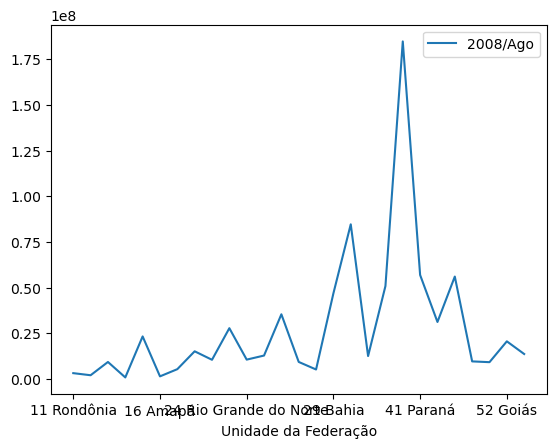

In [95]:
dados_2008.plot(x="Unidade da Federação", y="2008/Ago")

In [96]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

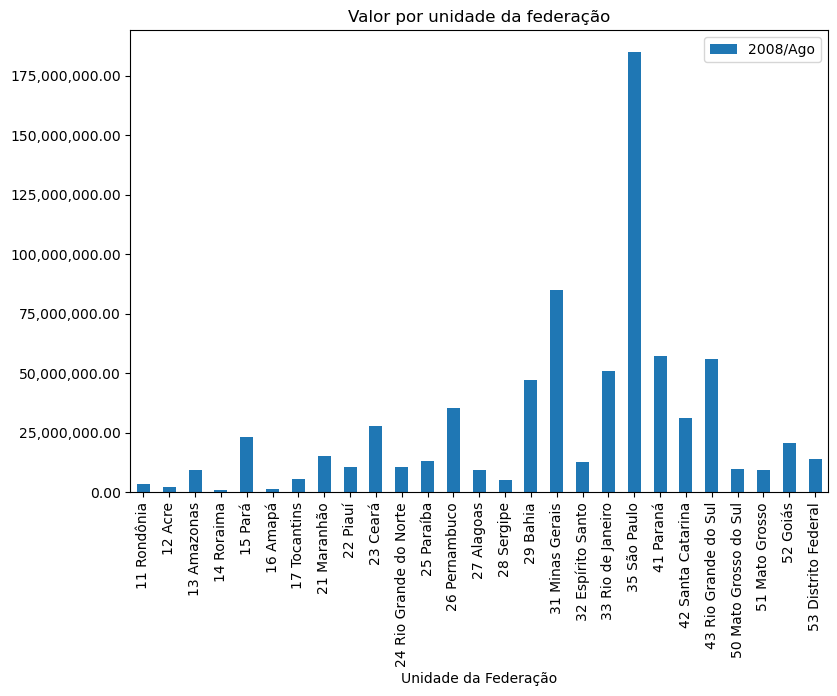

In [97]:
axis = dados_2008.plot(x="Unidade da Federação", y="2008/Ago", kind="bar", figsize=(9, 6))
axis.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.2f}'))

plt.title("Valor por unidade da federação")
plt.show()

## Desafio 2 - Ajustar o gráfico

In [98]:
colunas_if = ["Unidade da Federação", "index"]
y_coluna_mais_recente = max([col for col in dados_2008_recentes.columns if col not in colunas_if])

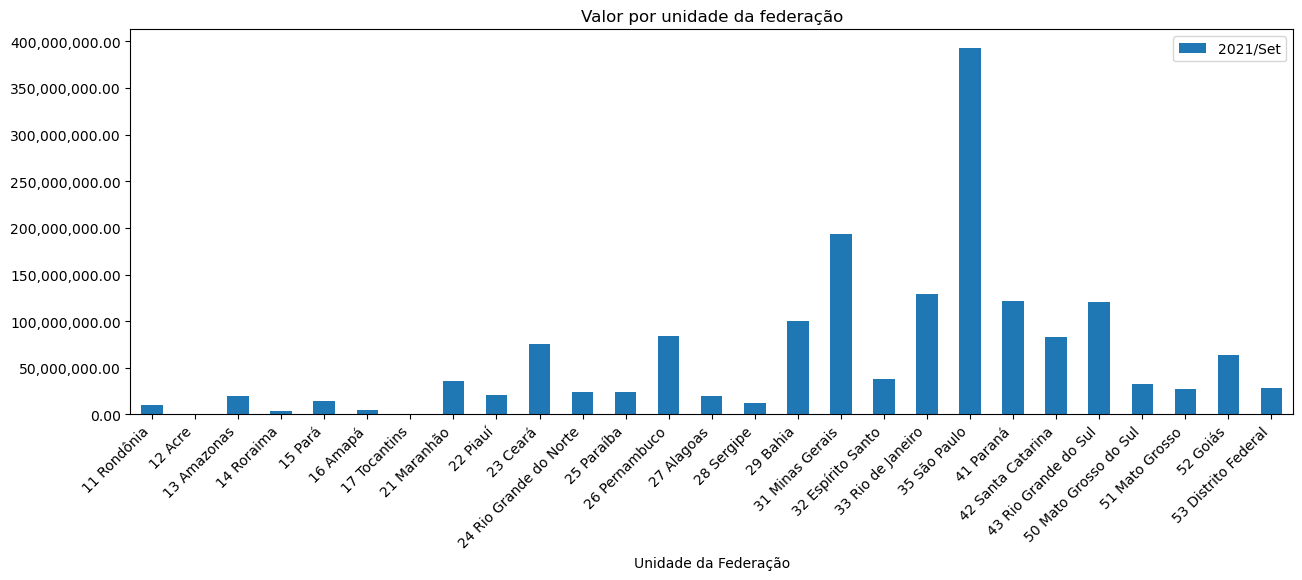

In [99]:
grafico = dados_2008_recentes.plot(x="Unidade da Federação", y=y_coluna_mais_recente, kind="bar", figsize=(15, 5))
grafico.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.2f}'))

plt.title("Valor por unidade da federação")
plt.xticks(rotation=45, ha="right", va="top")
plt.show()

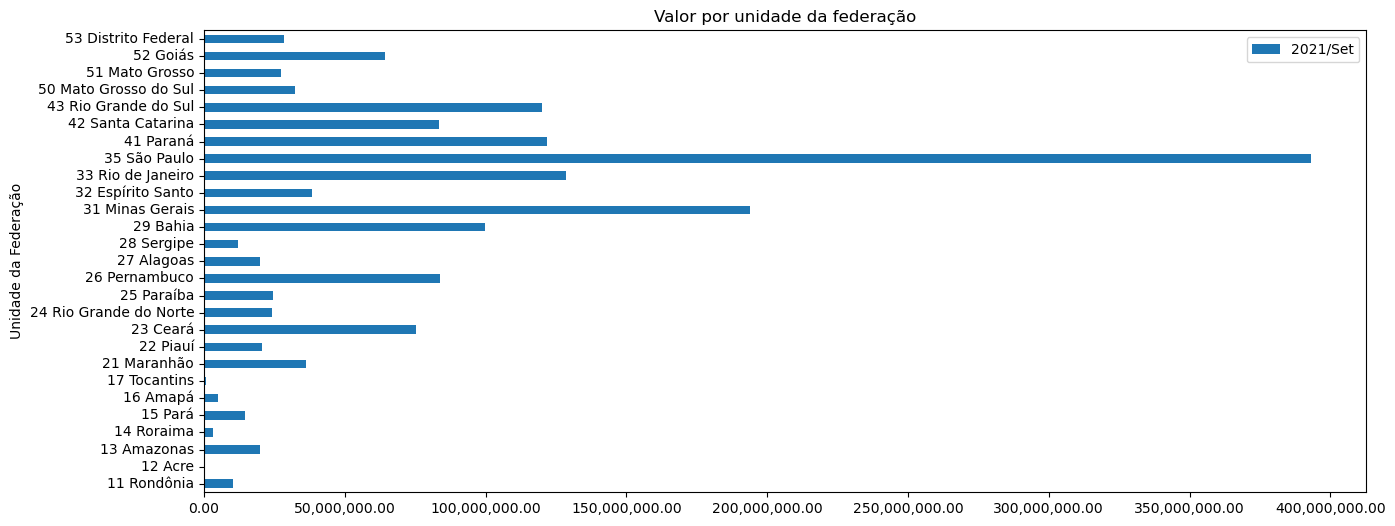

In [100]:
grafico = dados_2008_recentes.plot(x="Unidade da Federação", y=y_coluna_mais_recente, kind="barh", figsize=(15, 6))
grafico.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.2f}'))

plt.title("Valor por unidade da federação")
plt.yticks(rotation=0, ha="right", va="center")

plt.show()

# Aula 3 - Manipulação de Dados

## Códigos executados na aula

In [101]:
# Ler o arquivo .csv e gerar um data frame
if "COLAB_GPU" in os.environ:
    caminho_arquivo = "/content/A150850189_28_143_208.csv"

else:
    caminho_arquivo = r"C:\Users\ricar\OneDrive\Cursos\Pós Graduação\Data Analytics - FIAP\02 - Fase 1 - Data Analysis and Exploration\02 - Análise exploratória de dados\Bases\A150850189_28_143_208.csv"

dados_full = pd.read_csv(caminho_arquivo, encoding="ISO-8859-1", skiprows=3, sep=";",
                     skipfooter=12, thousands=".", decimal=",", engine="python")

In [102]:
dados_full.head()

,Unidade da Federação,1992/Mar,1992/Abr,1993/Mai,1993/Dez,1994/Jan,1994/Fev,1994/Mai,1994/Ago,1994/Nov,...,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,2021/Set,Total
0,11 Rondônia,-,-,-,-,-,-,-,-,-,...,10045624.39,10677245.18,18147121.02,17753851.45,17659855.79,14435903.47,11834435.10,7371334.84,1682801.60,1088059702.25
1,12 Acre,-,-,-,-,-,-,-,-,-,...,4175526.06,5282655.42,5699597.78,5002272.59,4326882.24,3458187.11,2302711.01,1196754.85,-,475290315.34
2,13 Amazonas,-,-,-,-,-,-,-,-,-,...,27406458.57,22341042.63,27923786.94,24515920.09,23973537.71,22175398.40,21614943.55,13806958.66,5292323.36,2061943006.93
3,14 Roraima,-,-,-,-,-,-,-,-,-,...,3557821.99,4172285.82,5427226.70,4192540.54,3681417.80,3475205.55,3320807.96,2907871.07,1496814.75,352546288.71
4,15 Pará,-,-,-,-,-,-,-,-,-,...,39042349.46,37113440.70,49625416.13,52558327.29,50907226.77,43876590.47,33718084.12,20837865.89,4620263.03,4968811817.17


In [103]:
dados_numericos_full = dados_full.select_dtypes(include=['number'])
dados_numericos_full.mean()

2007/Ago       304952.77
2007/Set       788145.26
2007/Out      2440162.96
2007/Nov      5517354.05
2007/Dez     12337159.42
                ...     
2021/Mai     87271862.20
2021/Jun     77590406.47
2021/Jul     60846287.01
2021/Ago     43885716.30
Total      6852320913.49
Length: 170, dtype: float64

In [104]:
colunas_usaveis = dados_numericos_full.mean().index.tolist()
colunas_usaveis.insert(0, 'Unidade da Federação')
colunas_usaveis[:5]

['Unidade da Federação', '2007/Ago', '2007/Set', '2007/Out', '2007/Nov']

In [105]:
dados_usaveis = dados_full[colunas_usaveis]
dados_usaveis.head()

,Unidade da Federação,2007/Ago,2007/Set,2007/Out,2007/Nov,2007/Dez,2008/Jan,2008/Fev,2008/Mar,2008/Abr,...,2020/Dez,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,Total
0,11 Rondônia,4209.37,16397.03,133645.19,346912.84,711758.31,1829559.71,1940792.63,1955721.68,2143353.81,...,9469279.43,10045624.39,10677245.18,18147121.02,17753851.45,17659855.79,14435903.47,11834435.10,7371334.84,1088059702.25
1,12 Acre,10470.07,14001.71,86200.85,301323.68,769612.36,1731744.62,1743978.66,2057439.02,2057829.69,...,3820865.83,4175526.06,5282655.42,5699597.78,5002272.59,4326882.24,3458187.11,2302711.01,1196754.85,475290315.34
2,13 Amazonas,35752.72,45570.64,416012.30,2020381.79,5949408.99,11419210.08,7934652.10,8641517.13,8531576.49,...,21911210.94,27406458.57,22341042.63,27923786.94,24515920.09,23973537.71,22175398.40,21614943.55,13806958.66,2061943006.93
3,14 Roraima,4785.91,11858.63,43852.67,369328.51,470676.43,808448.39,771687.83,876091.18,896952.53,...,3193708.89,3557821.99,4172285.82,5427226.70,4192540.54,3681417.80,3475205.55,3320807.96,2907871.07,352546288.71
4,15 Pará,181159.29,433414.74,1893197.50,5105406.44,13162823.43,21762104.16,20126081.01,22149375.82,23436682.75,...,37925512.28,39042349.46,37113440.70,49625416.13,52558327.29,50907226.77,43876590.47,33718084.12,20837865.89,4968811817.17


In [106]:
dados_usaveis = dados_usaveis.set_index('Unidade da Federação')
dados_usaveis.head()

,2007/Ago,2007/Set,2007/Out,2007/Nov,2007/Dez,2008/Jan,2008/Fev,2008/Mar,2008/Abr,2008/Mai,...,2020/Dez,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,Total
Unidade da Federação,,,,,,,,,,,,,,,,,,,,,
11 Rondônia,4209.37,16397.03,133645.19,346912.84,711758.31,1829559.71,1940792.63,1955721.68,2143353.81,2280382.58,...,9469279.43,10045624.39,10677245.18,18147121.02,17753851.45,17659855.79,14435903.47,11834435.10,7371334.84,1088059702.25
12 Acre,10470.07,14001.71,86200.85,301323.68,769612.36,1731744.62,1743978.66,2057439.02,2057829.69,2226577.93,...,3820865.83,4175526.06,5282655.42,5699597.78,5002272.59,4326882.24,3458187.11,2302711.01,1196754.85,475290315.34
13 Amazonas,35752.72,45570.64,416012.30,2020381.79,5949408.99,11419210.08,7934652.10,8641517.13,8531576.49,9079902.15,...,21911210.94,27406458.57,22341042.63,27923786.94,24515920.09,23973537.71,22175398.40,21614943.55,13806958.66,2061943006.93
14 Roraima,4785.91,11858.63,43852.67,369328.51,470676.43,808448.39,771687.83,876091.18,896952.53,1027288.73,...,3193708.89,3557821.99,4172285.82,5427226.70,4192540.54,3681417.80,3475205.55,3320807.96,2907871.07,352546288.71
15 Pará,181159.29,433414.74,1893197.50,5105406.44,13162823.43,21762104.16,20126081.01,22149375.82,23436682.75,23861080.80,...,37925512.28,39042349.46,37113440.70,49625416.13,52558327.29,50907226.77,43876590.47,33718084.12,20837865.89,4968811817.17


In [107]:
# .loc é usado para buscar pelo indice
dados_usaveis.loc["12 Acre"]

2007/Ago       10470.07
2007/Set       14001.71
2007/Out       86200.85
2007/Nov      301323.68
2007/Dez      769612.36
               ...     
2021/Mai     4326882.24
2021/Jun     3458187.11
2021/Jul     2302711.01
2021/Ago     1196754.85
Total      475290315.34
Name: 12 Acre, Length: 170, dtype: float64

In [108]:
# .iloc é usado para localizar através do contador i
dados_usaveis.iloc[1]

2007/Ago       10470.07
2007/Set       14001.71
2007/Out       86200.85
2007/Nov      301323.68
2007/Dez      769612.36
               ...     
2021/Mai     4326882.24
2021/Jun     3458187.11
2021/Jul     2302711.01
2021/Ago     1196754.85
Total      475290315.34
Name: 12 Acre, Length: 170, dtype: float64

<Axes: xlabel='Unidade da Federação'>

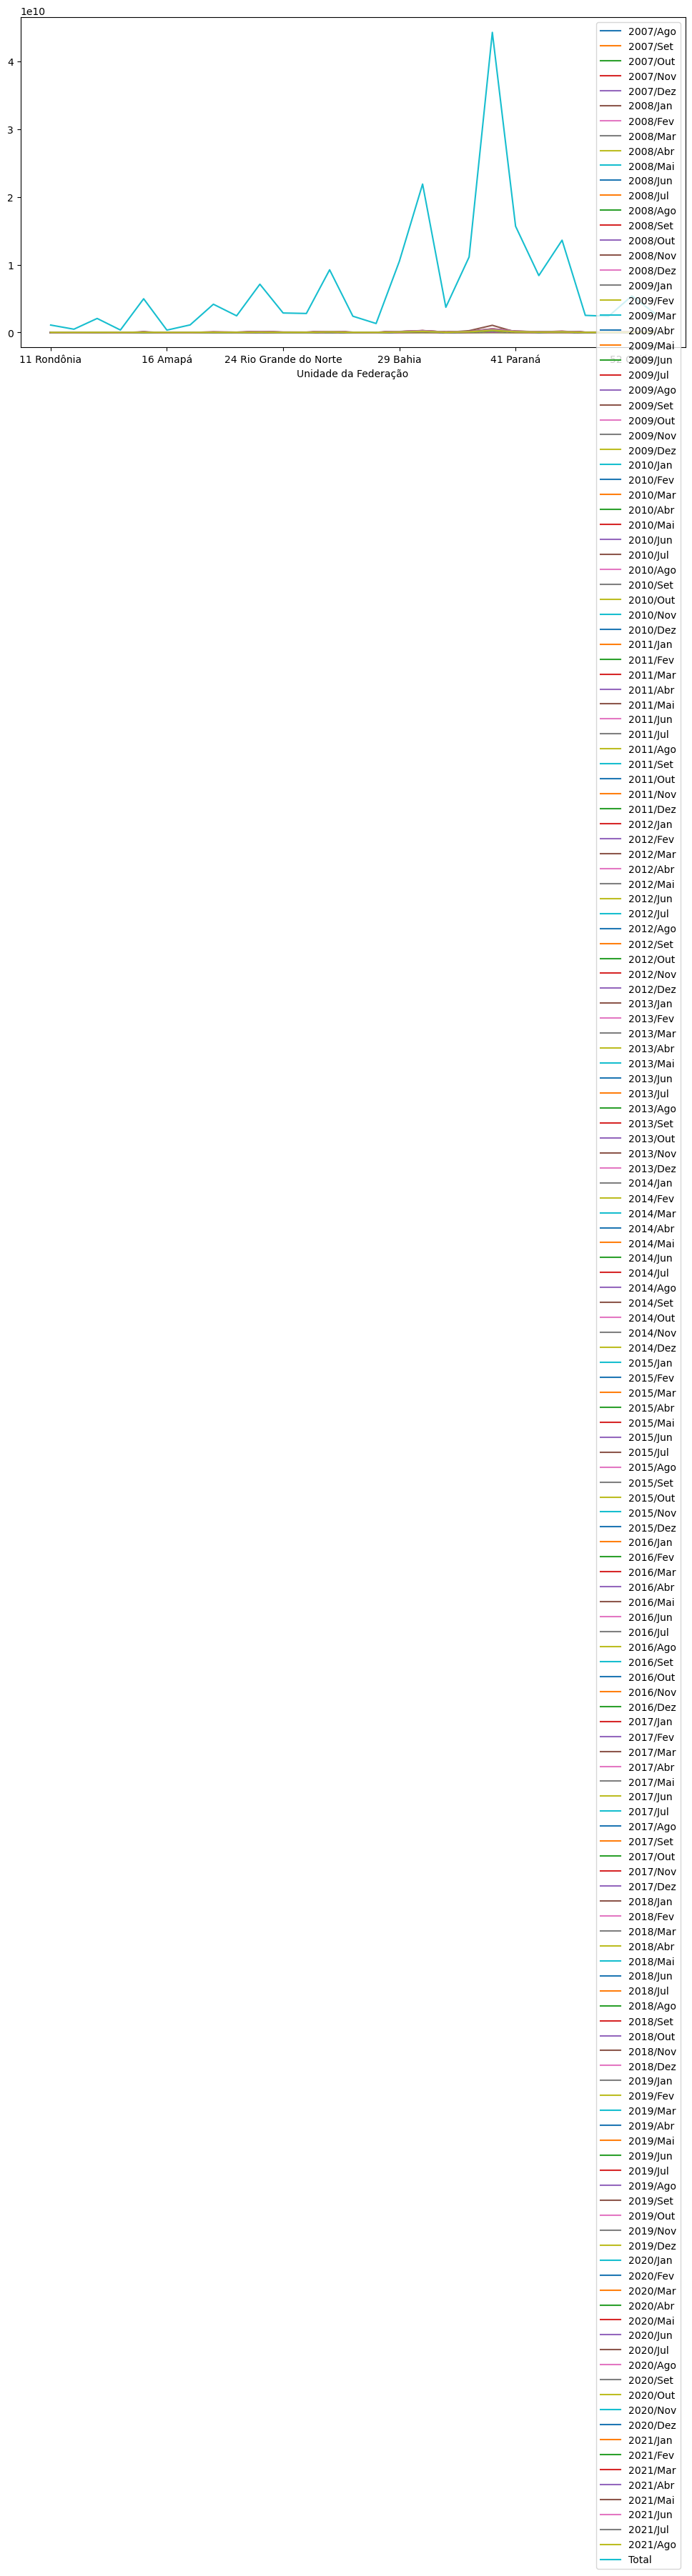

In [109]:
dados_usaveis.plot(figsize=(12,6))

In [110]:
dados_usaveis.T.head()

Unidade da Federação,11 Rondônia,12 Acre,13 Amazonas,14 Roraima,15 Pará,16 Amapá,17 Tocantins,21 Maranhão,22 Piauí,23 Ceará,...,32 Espírito Santo,33 Rio de Janeiro,35 São Paulo,41 Paraná,42 Santa Catarina,43 Rio Grande do Sul,50 Mato Grosso do Sul,51 Mato Grosso,52 Goiás,53 Distrito Federal
2007/Ago,4209.37,10470.07,35752.72,4785.91,181159.29,33672.74,4113.76,385330.18,220788.25,357904.65,...,57408.11,469469.34,1665349.90,554800.22,693955.05,1049252.33,199556.12,63562.50,179395.82,191951.47
2007/Set,16397.03,14001.71,45570.64,11858.63,433414.74,104822.98,76633.06,1018352.93,353468.67,572356.18,...,284224.80,921646.57,4434168.64,1431708.01,1092964.12,3182913.14,573675.41,232444.62,418053.58,769966.25
2007/Out,133645.19,86200.85,416012.30,43852.67,1893197.50,118378.28,343702.61,2277717.78,1078182.68,1865065.71,...,1152115.25,2994664.57,14577395.84,4630402.44,3562300.82,8571312.11,1069816.66,927219.59,1198730.25,2165619.56
2007/Nov,346912.84,301323.68,2020381.79,369328.51,5105406.44,226661.18,1068685.94,4334468.23,2406035.32,5131814.39,...,2296383.23,7250528.08,35032259.98,11120030.79,7578502.38,16592432.80,1995899.52,1740439.60,2712117.54,3813256.48
2007/Dez,711758.31,769612.36,5949408.99,470676.43,13162823.43,844019.90,3022200.87,8832514.85,4929772.93,10798042.86,...,5724199.54,13627123.27,76668547.41,28790722.87,14772555.10,30134255.70,4277979.14,5394225.43,9293914.78,7121965.42


<Axes: >

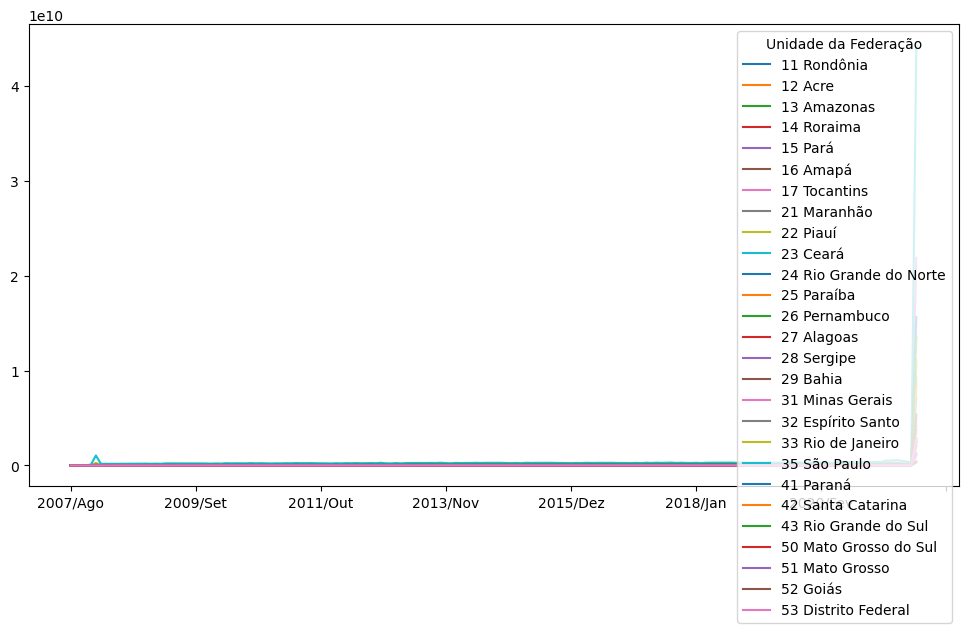

In [111]:
dados_usaveis.T.plot(figsize=(12,6))

In [112]:
dados_usaveis.T.tail()

Unidade da Federação,11 Rondônia,12 Acre,13 Amazonas,14 Roraima,15 Pará,16 Amapá,17 Tocantins,21 Maranhão,22 Piauí,23 Ceará,...,32 Espírito Santo,33 Rio de Janeiro,35 São Paulo,41 Paraná,42 Santa Catarina,43 Rio Grande do Sul,50 Mato Grosso do Sul,51 Mato Grosso,52 Goiás,53 Distrito Federal
2021/Mai,17659855.79,4326882.24,23973537.71,3681417.80,50907226.77,5672086.52,10161783.68,55324683.42,32550777.47,102825954.51,...,57345370.07,145372684.38,548112705.83,191861617.22,101661537.37,155084262.06,36885633.11,37859473.58,69467332.76,32434557.27
2021/Jun,14435903.47,3458187.11,22175398.40,3475205.55,43876590.47,5469150.38,6349488.16,51958573.27,26015797.57,81919446.05,...,48137665.89,124909043.81,503160959.54,163580936.16,93055772.86,142812283.70,31595196.27,34937134.14,67162348.93,27196457.00
2021/Jul,11834435.10,2302711.01,21614943.55,3320807.96,33718084.12,4136950.62,4610170.61,37775425.78,19972846.10,57727138.38,...,36550871.52,113660882.20,404373175.61,119408026.56,70531971.21,112805351.92,20711974.43,29364200.76,57891285.60,26265515.44
2021/Ago,7371334.84,1196754.85,13806958.66,2907871.07,20837865.89,1875241.91,2304080.49,25779674.83,15220885.72,35650007.47,...,27127454.08,94137361.39,301986341.98,91187722.64,48884998.15,74954589.62,11302985.98,19849249.43,44939821.34,22156437.60
Total,1088059702.25,475290315.34,2061943006.93,352546288.71,4968811817.17,337181964.14,1110344733.46,4161325769.23,2450508593.82,7118540187.61,...,3710941856.86,11131868548.73,44290790025.14,15672157558.11,8392938841.37,13613341350.00,2516383489.01,2386584382.72,5380179246.60,2778456616.77


In [113]:
dados_usaveis = dados_usaveis.drop('Total', axis=1)
dados_usaveis.head()

,2007/Ago,2007/Set,2007/Out,2007/Nov,2007/Dez,2008/Jan,2008/Fev,2008/Mar,2008/Abr,2008/Mai,...,2020/Nov,2020/Dez,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago
Unidade da Federação,,,,,,,,,,,,,,,,,,,,,
11 Rondônia,4209.37,16397.03,133645.19,346912.84,711758.31,1829559.71,1940792.63,1955721.68,2143353.81,2280382.58,...,8909539.74,9469279.43,10045624.39,10677245.18,18147121.02,17753851.45,17659855.79,14435903.47,11834435.10,7371334.84
12 Acre,10470.07,14001.71,86200.85,301323.68,769612.36,1731744.62,1743978.66,2057439.02,2057829.69,2226577.93,...,3497348.48,3820865.83,4175526.06,5282655.42,5699597.78,5002272.59,4326882.24,3458187.11,2302711.01,1196754.85
13 Amazonas,35752.72,45570.64,416012.30,2020381.79,5949408.99,11419210.08,7934652.10,8641517.13,8531576.49,9079902.15,...,20587412.38,21911210.94,27406458.57,22341042.63,27923786.94,24515920.09,23973537.71,22175398.40,21614943.55,13806958.66
14 Roraima,4785.91,11858.63,43852.67,369328.51,470676.43,808448.39,771687.83,876091.18,896952.53,1027288.73,...,3531874.44,3193708.89,3557821.99,4172285.82,5427226.70,4192540.54,3681417.80,3475205.55,3320807.96,2907871.07
15 Pará,181159.29,433414.74,1893197.50,5105406.44,13162823.43,21762104.16,20126081.01,22149375.82,23436682.75,23861080.80,...,37228236.49,37925512.28,39042349.46,37113440.70,49625416.13,52558327.29,50907226.77,43876590.47,33718084.12,20837865.89


In [114]:
dados_usaveis.tail()

,2007/Ago,2007/Set,2007/Out,2007/Nov,2007/Dez,2008/Jan,2008/Fev,2008/Mar,2008/Abr,2008/Mai,...,2020/Nov,2020/Dez,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago
Unidade da Federação,,,,,,,,,,,,,,,,,,,,,
43 Rio Grande do Sul,1049252.33,3182913.14,8571312.11,16592432.80,30134255.70,51064610.03,45897704.82,52928695.92,51972416.77,51679350.79,...,117696633.24,120291289.00,115991861.17,126730284.94,169687680.33,145302546.19,155084262.06,142812283.70,112805351.92,74954589.62
50 Mato Grosso do Sul,199556.12,573675.41,1069816.66,1995899.52,4277979.14,8301006.10,8279288.79,9793888.78,8997542.75,9842108.59,...,21944586.48,25069724.67,24727004.66,25600761.42,32506184.09,33101059.57,36885633.11,31595196.27,20711974.43,11302985.98
51 Mato Grosso,63562.50,232444.62,927219.59,1740439.60,5394225.43,8213438.64,7929894.93,9416367.68,9390588.03,9378197.25,...,18816500.60,19579997.79,18889711.53,21544594.04,35790837.70,37534015.20,37859473.58,34937134.14,29364200.76,19849249.43
52 Goiás,179395.82,418053.58,1198730.25,2712117.54,9293914.78,76052094.77,18149374.27,20992213.03,21049477.30,19162546.79,...,41343113.77,41133178.65,42638703.48,45715467.93,74464062.86,68630407.92,69467332.76,67162348.93,57891285.60,44939821.34
53 Distrito Federal,191951.47,769966.25,2165619.56,3813256.48,7121965.42,10561085.46,10215956.80,11627918.26,11922015.36,11900817.00,...,20747736.49,22822625.40,24484716.93,24156062.77,36391034.41,35641761.42,32434557.27,27196457.00,26265515.44,22156437.60


<Axes: >

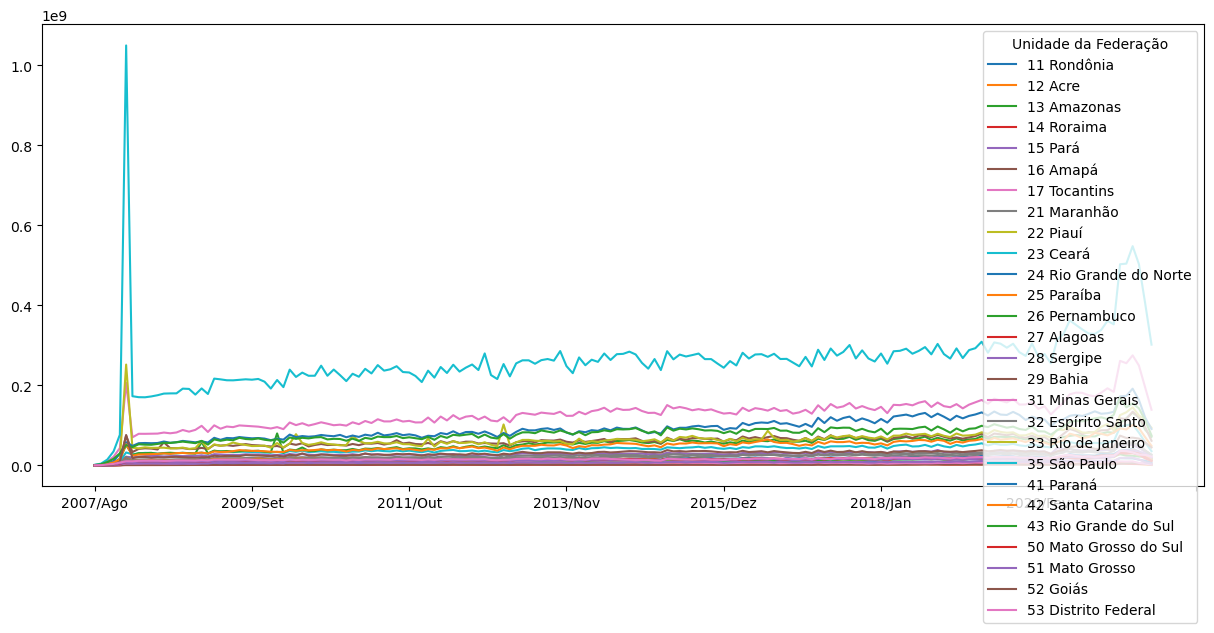

In [115]:
dados_usaveis.T.plot(figsize=(15,6))

# Desafio 3 - Ajustar o gráfico

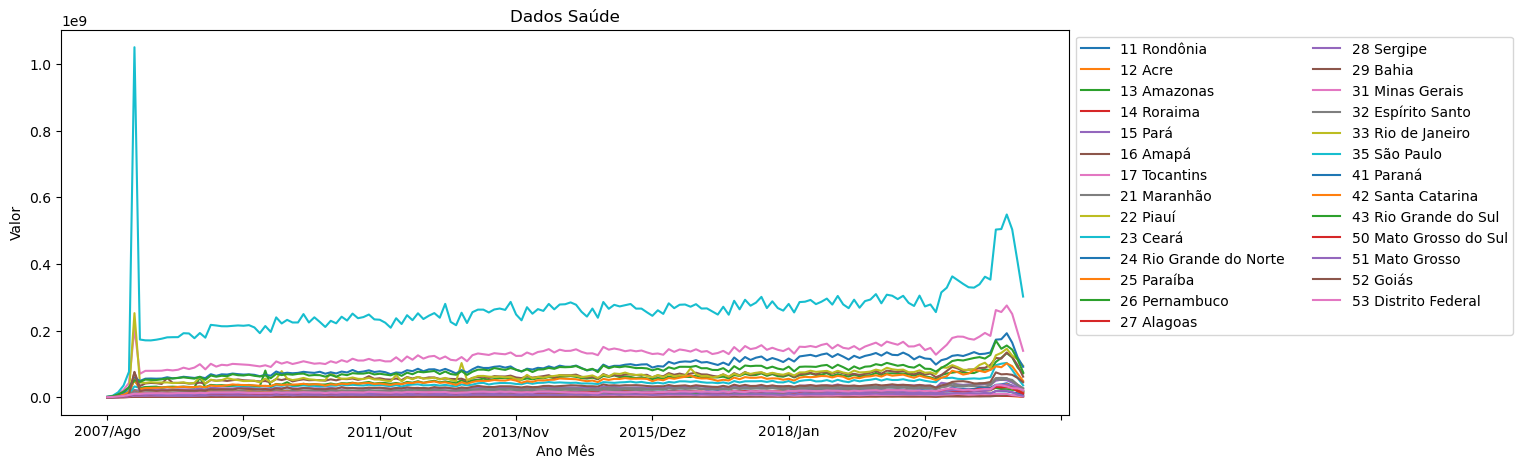

In [116]:
grafico = dados_usaveis.T.plot(figsize=(13,5))
grafico.set_title("Dados Saúde")
grafico.set_xlabel("Ano Mês")
grafico.set_ylabel("Valor")
grafico.legend(loc='upper left', bbox_to_anchor=(1,1), ncol=2)

In [117]:
# Verificar os nomes das colunas
dados_usaveis.T.columns

Index(['11 Rondônia', '12 Acre', '13 Amazonas', '14 Roraima', '15 Pará',
       '16 Amapá', '17 Tocantins', '21 Maranhão', '22 Piauí', '23 Ceará',
       '24 Rio Grande do Norte', '25 Paraíba', '26 Pernambuco', '27 Alagoas',
       '28 Sergipe', '29 Bahia', '31 Minas Gerais', '32 Espírito Santo',
       '33 Rio de Janeiro', '35 São Paulo', '41 Paraná', '42 Santa Catarina',
       '43 Rio Grande do Sul', '50 Mato Grosso do Sul', '51 Mato Grosso',
       '52 Goiás', '53 Distrito Federal'],
      dtype='object', name='Unidade da Federação')

<Axes: >

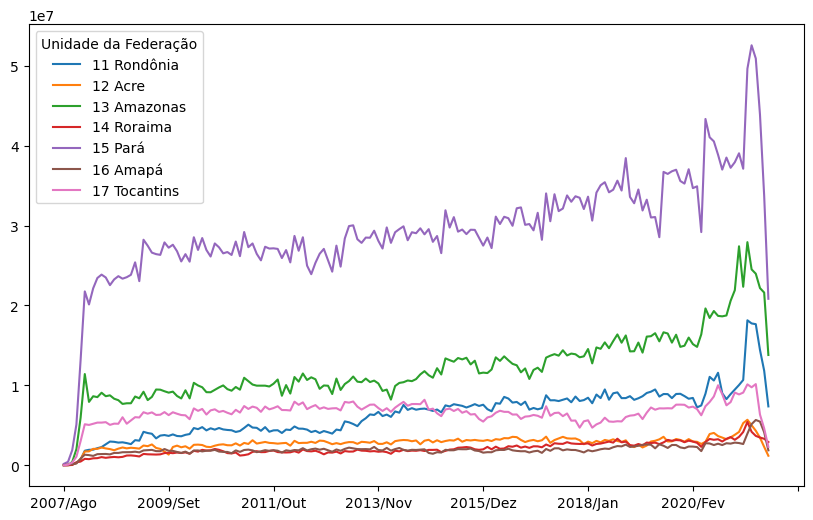

In [118]:
# Plotar apenas os 7 primeiros dados
dados_usaveis[:7].T.plot(figsize=(10,6))

In [119]:
# Retornar os dados de uma linha aleatória
dados_usaveis.sample()

,2007/Ago,2007/Set,2007/Out,2007/Nov,2007/Dez,2008/Jan,2008/Fev,2008/Mar,2008/Abr,2008/Mai,...,2020/Nov,2020/Dez,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago
Unidade da Federação,,,,,,,,,,,,,,,,,,,,,
43 Rio Grande do Sul,1049252.33,3182913.14,8571312.11,16592432.80,30134255.70,51064610.03,45897704.82,52928695.92,51972416.77,51679350.79,...,117696633.24,120291289.00,115991861.17,126730284.94,169687680.33,145302546.19,155084262.06,142812283.70,112805351.92,74954589.62


In [120]:
# Retornar os dados de 7 linhas aleatórias
dados_usaveis.sample(n=7)

,2007/Ago,2007/Set,2007/Out,2007/Nov,2007/Dez,2008/Jan,2008/Fev,2008/Mar,2008/Abr,2008/Mai,...,2020/Nov,2020/Dez,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago
Unidade da Federação,,,,,,,,,,,,,,,,,,,,,
13 Amazonas,35752.72,45570.64,416012.30,2020381.79,5949408.99,11419210.08,7934652.10,8641517.13,8531576.49,9079902.15,...,20587412.38,21911210.94,27406458.57,22341042.63,27923786.94,24515920.09,23973537.71,22175398.40,21614943.55,13806958.66
27 Alagoas,104243.75,174024.90,595544.54,1125396.73,2564966.65,16623799.85,8112220.30,9210505.56,10466691.94,9844096.03,...,19163373.25,18566269.71,20154290.67,21539842.43,30875169.00,29413996.17,30550686.94,26888254.59,17475906.50,11393875.70
23 Ceará,357904.65,572356.18,1865065.71,5131814.39,10798042.86,32444328.54,27643304.86,30085370.22,31376221.00,31189904.62,...,56448415.00,55331920.85,57451589.31,60105521.76,96063868.02,100543749.33,102825954.51,81919446.05,57727138.38,35650007.47
53 Distrito Federal,191951.47,769966.25,2165619.56,3813256.48,7121965.42,10561085.46,10215956.80,11627918.26,11922015.36,11900817.00,...,20747736.49,22822625.40,24484716.93,24156062.77,36391034.41,35641761.42,32434557.27,27196457.00,26265515.44,22156437.60
32 Espírito Santo,57408.11,284224.80,1152115.25,2296383.23,5724199.54,16212109.41,10032886.43,12262049.08,12453466.98,11789786.09,...,36365933.28,42256604.54,40664905.15,39529966.31,57618664.94,58031849.50,57345370.07,48137665.89,36550871.52,27127454.08
35 São Paulo,1665349.90,4434168.64,14577395.84,35032259.98,76668547.41,1049827695.26,173062308.33,170621304.31,170389849.75,172513744.39,...,328687791.75,338634303.39,361427087.80,352846447.86,502905607.53,504427182.45,548112705.83,503160959.54,404373175.61,301986341.98
51 Mato Grosso,63562.50,232444.62,927219.59,1740439.60,5394225.43,8213438.64,7929894.93,9416367.68,9390588.03,9378197.25,...,18816500.60,19579997.79,18889711.53,21544594.04,35790837.70,37534015.20,37859473.58,34937134.14,29364200.76,19849249.43


<Axes: >

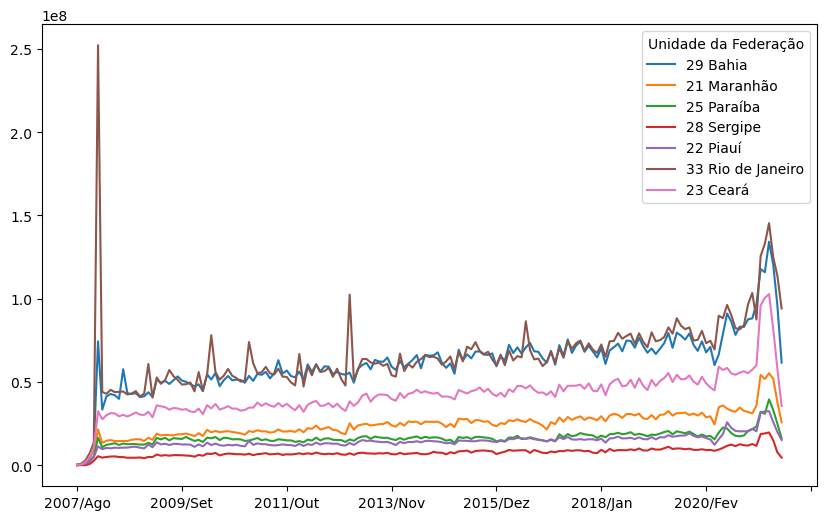

In [121]:
dados_usaveis.sample(7).T.plot(figsize=(10,6))

In [122]:
# Biblioteca para trabalhar com dados numéricos
import numpy as np

In [123]:
np.random.seed(524387)
dados_usaveis.sample(n=7)

,2007/Ago,2007/Set,2007/Out,2007/Nov,2007/Dez,2008/Jan,2008/Fev,2008/Mar,2008/Abr,2008/Mai,...,2020/Nov,2020/Dez,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago
Unidade da Federação,,,,,,,,,,,,,,,,,,,,,
17 Tocantins,4113.76,76633.06,343702.61,1068685.94,3022200.87,5136474.61,5051932.07,5200151.87,5343714.73,5344487.99,...,7909740.70,9104099.56,8868698.71,9098989.10,10129712.88,9762980.73,10161783.68,6349488.16,4610170.61,2304080.49
26 Pernambuco,400640.85,1088340.42,2973553.48,6699828.82,16919031.39,51279301.86,26222079.10,30716361.81,30589332.79,31424612.72,...,72557211.47,79476638.20,83144993.84,81741861.37,105871865.99,118218034.52,132095684.99,119545888.06,89156304.23,71625844.36
31 Minas Gerais,971394.37,2861781.50,10018011.35,21730281.63,43429517.54,206493861.30,70301089.50,79119005.51,79046322.41,79268070.12,...,172730921.65,181833354.32,192844182.05,183891512.07,261376726.91,255545757.83,275151838.35,249713866.70,194734136.81,139157823.59
22 Piauí,220788.25,353468.67,1078182.68,2406035.32,4929772.93,11375419.37,9711680.20,10428191.09,10227943.00,10562148.66,...,20466879.33,20331213.19,21839112.13,20414695.91,31586481.13,32367250.52,32550777.47,26015797.57,19972846.10,15220885.72
25 Paraíba,97352.78,368130.43,1002088.64,2149873.40,5448177.36,16599004.84,10871589.62,12348758.14,12680965.13,13258411.71,...,17875939.21,20704186.30,21740778.25,23328004.56,32197966.23,30904806.65,39602463.80,33149421.34,24925842.39,16167879.55
29 Bahia,135146.36,448349.75,1382038.11,3348779.62,11948984.56,74456787.96,33410124.06,41329594.35,42826993.62,42099192.56,...,83082385.00,87649577.75,88213804.44,96878079.79,117816174.41,115928975.22,134229720.19,120516112.40,95691895.48,61645689.06
42 Santa Catarina,693955.05,1092964.12,3562300.82,7578502.38,14772555.10,53034384.67,24409572.92,27483480.50,27806641.44,28354279.52,...,81200552.61,79268003.38,75238574.26,82034122.92,92581408.31,89976929.76,101661537.37,93055772.86,70531971.21,48884998.15


<Axes: >

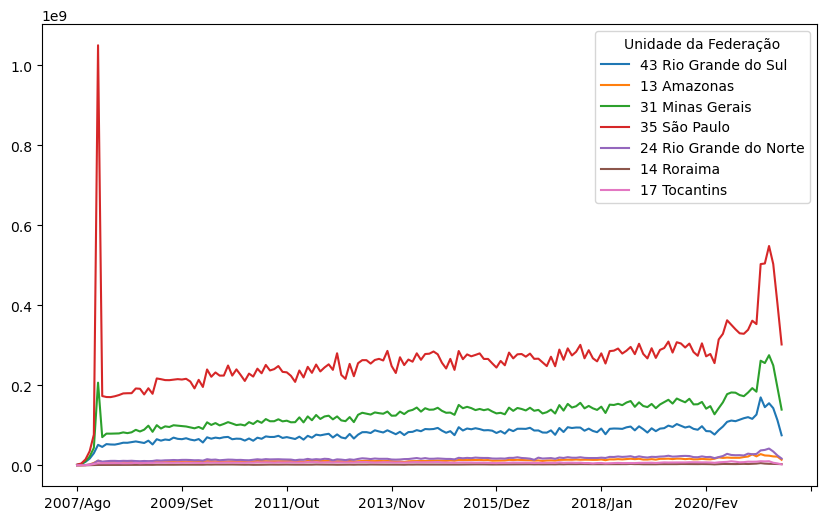

In [124]:
dados_usaveis.sample(n=7).T.plot(figsize=(10,6))

In [125]:
dados_usaveis["Total"] = dados_usaveis.sum(axis=1)
dados_usaveis.head()

,2007/Ago,2007/Set,2007/Out,2007/Nov,2007/Dez,2008/Jan,2008/Fev,2008/Mar,2008/Abr,2008/Mai,...,2020/Dez,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,Total
Unidade da Federação,,,,,,,,,,,,,,,,,,,,,
11 Rondônia,4209.37,16397.03,133645.19,346912.84,711758.31,1829559.71,1940792.63,1955721.68,2143353.81,2280382.58,...,9469279.43,10045624.39,10677245.18,18147121.02,17753851.45,17659855.79,14435903.47,11834435.10,7371334.84,1086376296.32
12 Acre,10470.07,14001.71,86200.85,301323.68,769612.36,1731744.62,1743978.66,2057439.02,2057829.69,2226577.93,...,3820865.83,4175526.06,5282655.42,5699597.78,5002272.59,4326882.24,3458187.11,2302711.01,1196754.85,475289031.52
13 Amazonas,35752.72,45570.64,416012.30,2020381.79,5949408.99,11419210.08,7934652.10,8641517.13,8531576.49,9079902.15,...,21911210.94,27406458.57,22341042.63,27923786.94,24515920.09,23973537.71,22175398.40,21614943.55,13806958.66,2056647852.16
14 Roraima,4785.91,11858.63,43852.67,369328.51,470676.43,808448.39,771687.83,876091.18,896952.53,1027288.73,...,3193708.89,3557821.99,4172285.82,5427226.70,4192540.54,3681417.80,3475205.55,3320807.96,2907871.07,351049060.27
15 Pará,181159.29,433414.74,1893197.50,5105406.44,13162823.43,21762104.16,20126081.01,22149375.82,23436682.75,23861080.80,...,37925512.28,39042349.46,37113440.70,49625416.13,52558327.29,50907226.77,43876590.47,33718084.12,20837865.89,4964173018.54


# Desafio 4 - Ajustar o gráfico

In [126]:
# Ler o arquivo .csv e gerar um data frame
if "COLAB_GPU" in os.environ:
    caminho_arquivo = "/content/A152918189_28_143_208.csv"

else:
    caminho_arquivo = r"C:\Users\ricar\OneDrive\Cursos\Pós Graduação\Data Analytics - FIAP\02 - Fase 1 - Data Analysis and Exploration\02 - Análise exploratória de dados\Bases\A152918189_28_143_208.csv"

dados_usaveis_order = pd.read_csv(caminho_arquivo, encoding="ISO-8859-1", skiprows=3, sep=";",
                     skipfooter=12, thousands=".", decimal=",", engine="python")

In [127]:
dados_usaveis_order.head()

,Unidade da Federação,2008/Jan,2008/Fev,2008/Mar,2008/Abr,2008/Mai,2008/Jun,2008/Jul,2008/Ago,2008/Set,...,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,2021/Set,Total
0,11 Rondônia,1388528.39,2931283.42,1541682.52,1525314.96,1645953.84,1406150.68,3065279.01,3231494.61,3117178.63,...,9858841.18,9806315.07,14946369.28,15552930.66,16269008.71,15380532.08,14228814.25,12427865.05,10345616.78,1088059702.25
1,12 Acre,902416.00,1497206.26,1794028.48,1730469.42,1819443.92,1828496.00,2511754.59,2089107.14,2275708.53,...,3715723.12,3538427.92,4077045.92,6307616.67,6354514.15,3461663.11,4979239.30,4138751.64,-,475290315.34
2,13 Amazonas,4735529.42,7118990.57,8196635.49,8259378.42,7831399.90,8477273.62,9368858.72,9352532.70,9363099.35,...,21621697.26,26163677.75,23445832.76,23154039.32,26127701.15,26447055.27,24457791.81,22731356.54,19840265.30,2061943006.93
3,14 Roraima,657889.53,777939.31,718688.03,839994.39,862347.96,832440.66,996693.09,894271.18,910424.17,...,3266928.47,3519773.73,4437161.10,5171370.92,4266254.94,3103979.88,3743330.65,3781921.16,3150835.05,352546288.71
4,15 Pará,18864744.11,19553758.20,21937342.70,20842829.69,23249952.88,23240687.56,24002223.56,23341218.03,25172261.32,...,38813794.18,39251569.26,40639703.77,46608262.09,55310881.51,48215050.10,45801750.84,43262884.30,14569318.55,4968811817.17


In [128]:
# Ordernar os dados
dados_usaveis_order = dados_usaveis_order.sort_values(by='Total', ascending=False)

# Criar uma nova coluna com o código
dados_usaveis_order["Código"] = dados_usaveis_order["Unidade da Federação"].str.split().str[0]

# Extrair o código mantendo apenas o UF 
dados_usaveis_order["Unidade da Federação"] = dados_usaveis_order["Unidade da Federação"].str.split(n=1).str[1]

dados_usaveis_order[["Código","Unidade da Federação","Total"]].head()

,Código,Unidade da Federação,Total
19,35,São Paulo,44290985780.46
16,31,Minas Gerais,21899546392.60
20,41,Paraná,15672157558.11
22,43,Rio Grande do Sul,13613341350.00
18,33,Rio de Janeiro,11131869791.16


In [129]:
import requests
from lxml import html
import pandas as pd

# URL da página
url = "https://www.ibge.gov.br/explica/codigos-dos-municipios.php"

# Requisição
resposta = requests.get(url)
resposta.encoding = 'utf-8'  # Garante que acentos não quebrem

# Parse HTML
arvore = html.fromstring(resposta.content)

# Extrai os dados da tabela de UFs
ufs = arvore.xpath('//table[1]/tbody/tr/td[1]/a/text()')
codigos = arvore.xpath('//table[1]/tbody/tr/td[2]/a/text()')

# Monta o DataFrame
codigo_uf = pd.DataFrame({
    'Código': codigos,
    'UF': ufs
})

# Mapeamento de Código para Sigla e Região
mapa_uf = {
    '11': {'Sigla': 'RO', 'Região': 'Norte'},
    '12': {'Sigla': 'AC', 'Região': 'Norte'},
    '13': {'Sigla': 'AM', 'Região': 'Norte'},
    '14': {'Sigla': 'RR', 'Região': 'Norte'},
    '15': {'Sigla': 'PA', 'Região': 'Norte'},
    '16': {'Sigla': 'AP', 'Região': 'Norte'},
    '17': {'Sigla': 'TO', 'Região': 'Norte'},
    '21': {'Sigla': 'MA', 'Região': 'Nordeste'},
    '22': {'Sigla': 'PI', 'Região': 'Nordeste'},
    '23': {'Sigla': 'CE', 'Região': 'Nordeste'},
    '24': {'Sigla': 'RN', 'Região': 'Nordeste'},
    '25': {'Sigla': 'PB', 'Região': 'Nordeste'},
    '26': {'Sigla': 'PE', 'Região': 'Nordeste'},
    '27': {'Sigla': 'AL', 'Região': 'Nordeste'},
    '28': {'Sigla': 'SE', 'Região': 'Nordeste'},
    '29': {'Sigla': 'BA', 'Região': 'Nordeste'},
    '31': {'Sigla': 'MG', 'Região': 'Sudeste'},
    '32': {'Sigla': 'ES', 'Região': 'Sudeste'},
    '33': {'Sigla': 'RJ', 'Região': 'Sudeste'},
    '35': {'Sigla': 'SP', 'Região': 'Sudeste'},
    '41': {'Sigla': 'PR', 'Região': 'Sul'},
    '42': {'Sigla': 'SC', 'Região': 'Sul'},
    '43': {'Sigla': 'RS', 'Região': 'Sul'},
    '50': {'Sigla': 'MS', 'Região': 'Centro-Oeste'},
    '51': {'Sigla': 'MT', 'Região': 'Centro-Oeste'},
    '52': {'Sigla': 'GO', 'Região': 'Centro-Oeste'},
    '53': {'Sigla': 'DF', 'Região': 'Centro-Oeste'}
}

# Adiciona as colunas com base no mapeamento
codigo_uf['Sigla'] = codigo_uf['Código'].map(lambda x: mapa_uf.get(x, {}).get('Sigla'))
codigo_uf['Região'] = codigo_uf['Código'].map(lambda x: mapa_uf.get(x, {}).get('Região'))

# Exibe o DataFrame
codigo_uf


,Código,UF,Sigla,Região
0,12,Acre,AC,Norte
1,27,Alagoas,AL,Nordeste
2,16,Amapá,AP,Norte
3,13,Amazonas,AM,Norte
4,29,Bahia,BA,Nordeste
5,23,Ceará,CE,Nordeste
6,53,Distrito Federal,DF,Centro-Oeste
7,32,Espírito Santo,ES,Sudeste
8,52,Goiás,GO,Centro-Oeste
9,21,Maranhão,MA,Nordeste


In [130]:
dados_usaveis_join = dados_usaveis_order.merge(codigo_uf, how='left',on='Código')
dados_usaveis_join[["Unidade da Federação","Sigla","Região","Total"]].head()

,Unidade da Federação,Sigla,Região,Total
0,São Paulo,SP,Sudeste,44290985780.46
1,Minas Gerais,MG,Sudeste,21899546392.60
2,Paraná,PR,Sul,15672157558.11
3,Rio Grande do Sul,RS,Sul,13613341350.00
4,Rio de Janeiro,RJ,Sudeste,11131869791.16


In [131]:
# Garante resultados reproduzíveis
np.random.seed(524387)

# Separa São Paulo
sp = dados_usaveis_join[dados_usaveis_join["Sigla"] == "SP"]

# Sorteia 6 aleatórios sem São Paulo
outros = dados_usaveis_join[dados_usaveis_join["UF"] != "SP"].sample(n=6)

# 3. Junta tudo
amostra = pd.concat([sp, outros]).reset_index(drop=True)

amostra


,Unidade da Federação,2008/Jan,2008/Fev,2008/Mar,2008/Abr,2008/Mai,2008/Jun,2008/Jul,2008/Ago,2008/Set,...,2021/Mai,2021/Jun,2021/Jul,2021/Ago,2021/Set,Total,Código,UF,Sigla,Região
0,São Paulo,91678473.48,148677526.82,156087269.23,161227125.43,187119397.64,187291126.07,194398399.48,184854516.35,188636359.55,...,510118421.51,522748386.07,515461288.66,460348563.01,393119442.09,44290985780.46,35,São Paulo,SP,Sudeste
1,Pernambuco,14393949.89,24181400.95,29991302.71,34806197.97,32147987.35,32239094.89,32685640.76,35457038.66,33668261.46,...,123109445.78,125407650.08,114971565.52,102801016.63,83993757.90,9243658123.01,26,Pernambuco,PE,Nordeste
2,Espírito Santo,5456723.98,9102212.86,10249595.97,11253833.56,10198619.17,13364258.29,13035374.08,12588595.77,12727433.30,...,54019586.79,51416562.54,54431417.37,44627947.75,38395547.28,3710941856.86,32,Espírito Santo,ES,Sudeste
3,Mato Grosso do Sul,5377392.11,7002472.61,8423933.19,8797487.68,9770421.80,10905392.18,10249299.82,9671553.45,10218511.05,...,28649201.59,33920480.87,31552023.11,36310521.96,32338424.49,2516383489.01,50,Mato Grosso do Sul,MS,Centro-Oeste
4,Ceará,15539821.90,25735101.55,28724625.75,30676457.06,30604453.47,31272395.18,30925391.36,27851438.72,30362719.90,...,86928378.41,109909481.08,90387647.21,75731882.46,75197971.95,7118540187.61,23,Ceará,CE,Nordeste
5,Maranhão,10723506.39,13559679.41,13985142.36,14809416.46,14505727.38,14908091.32,15784899.40,15195312.89,14951277.75,...,52984947.37,50461554.99,50500013.97,41501696.81,36250671.51,4161325769.23,21,Maranhão,MA,Nordeste
6,Distrito Federal,4745919.19,7632480.67,9647203.26,11098732.99,12891719.72,12850125.67,12565646.74,13710857.89,13165106.20,...,31532816.86,30629361.48,29662716.67,27288766.94,28509985.96,2778456616.77,53,Distrito Federal,DF,Centro-Oeste


In [132]:
dados_usaveis_join_sudeste = dados_usaveis_join.copy()

dados_usaveis_join_sudeste = dados_usaveis_join_sudeste[dados_usaveis_join_sudeste["Região"] == "Sudeste"]

dados_usaveis_join_sudeste.head()

,Unidade da Federação,2008/Jan,2008/Fev,2008/Mar,2008/Abr,2008/Mai,2008/Jun,2008/Jul,2008/Ago,2008/Set,...,2021/Mai,2021/Jun,2021/Jul,2021/Ago,2021/Set,Total,Código,UF,Sigla,Região
0,São Paulo,91678473.48,148677526.82,156087269.23,161227125.43,187119397.64,187291126.07,194398399.48,184854516.35,188636359.55,...,510118421.51,522748386.07,515461288.66,460348563.01,393119442.09,44290985780.46,35,São Paulo,SP,Sudeste
1,Minas Gerais,45671659.76,70194037.10,79231336.95,77136537.58,80554440.63,94758522.83,85360064.11,84722528.10,84601757.95,...,251148575.23,265282411.52,258578548.60,241931842.85,193773519.61,21899546392.60,31,Minas Gerais,MG,Sudeste
4,Rio de Janeiro,23025258.52,28394310.93,44567062.94,44054604.82,44911021.15,48056212.24,49872379.35,50912706.60,49270352.76,...,133925004.72,133147569.87,132215973.66,133050914.66,128586740.23,11131869791.16,33,Rio de Janeiro,RJ,Sudeste
12,Espírito Santo,5456723.98,9102212.86,10249595.97,11253833.56,10198619.17,13364258.29,13035374.08,12588595.77,12727433.30,...,54019586.79,51416562.54,54431417.37,44627947.75,38395547.28,3710941856.86,32,Espírito Santo,ES,Sudeste


# Aula 4 - Análise de gráficos e criação de hipóteses

In [133]:
# Fazer uma copia do data frame - criar um novo data frame
dados_sudeste = dados_usaveis_join_sudeste.copy()

# Apagar as colunas que não precisamos
dados_sudeste = dados_sudeste.drop(columns=["Total", "Código", "UF", "Sigla", "Região","2008/Jan"])

# Fazer a coluna Unidade da Federação virar o indice
dados_sudeste = dados_sudeste.set_index('Unidade da Federação')

# Converter para número
dados_sudeste = dados_sudeste.apply(pd.to_numeric, errors='coerce')

In [134]:
# Transformar em notação cientifica 
dados_sudeste =  dados_sudeste / 1_000_000

Text(0.5, 0, 'Mês')

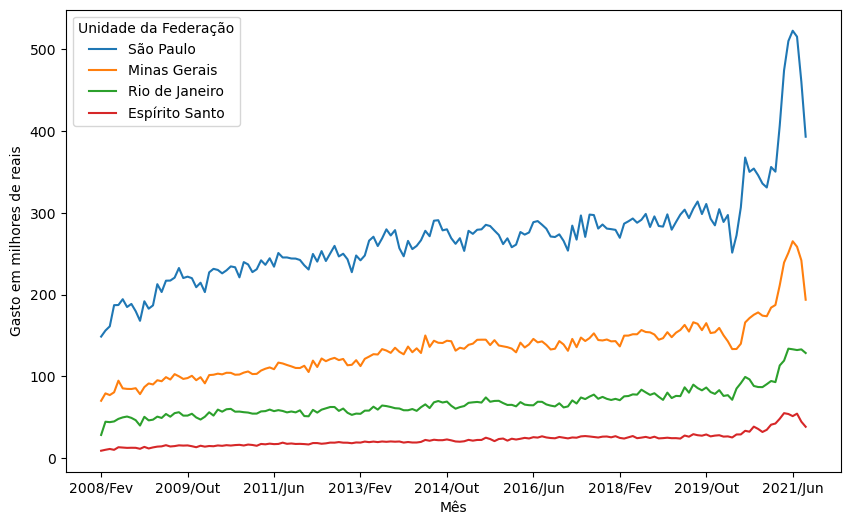

In [135]:
# Plotar o gráfico
axis = dados_sudeste.T.plot(figsize=(10,6))
axis.set_ylabel("Gasto em milhores de reais")
axis.set_xlabel("Mês")

Text(0.5, 0, 'Mês')

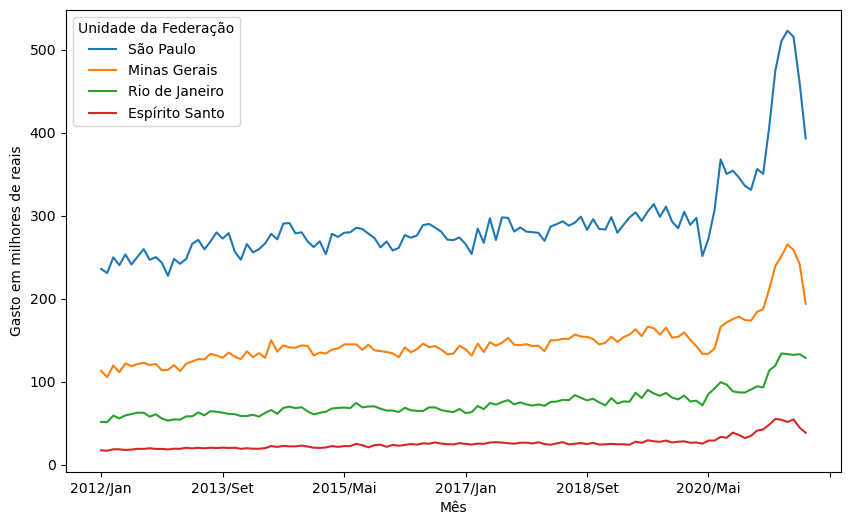

In [136]:
# Realizar o filtro dos dados a partir da coluna 47
meses_filtrados = dados_sudeste.columns[47:]
axis = dados_sudeste[meses_filtrados].T.plot(figsize=(10,6))
axis.set_ylabel("Gasto em milhores de reais")
axis.set_xlabel("Mês")

In [137]:
# Função para criar um gráfico 
def plota_gastos_por_mes(dados):
    axis = dados.T.plot(figsize=(10,6))
    axis.set_ylabel("Gasto em milhores de reais")
    axis.set_xlabel("Mês")

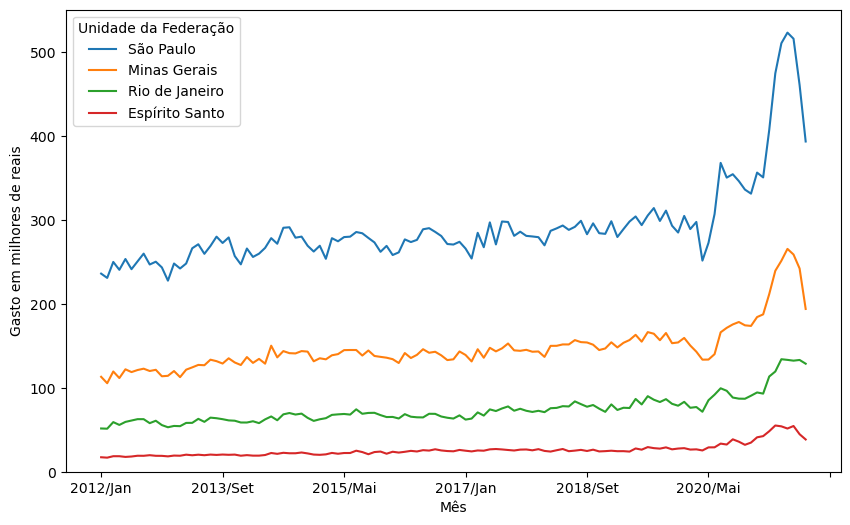

In [138]:
# Plotar o grafico via função
plota_gastos_por_mes(dados_sudeste[meses_filtrados])
plt.ylim(0,550)
plt.show()

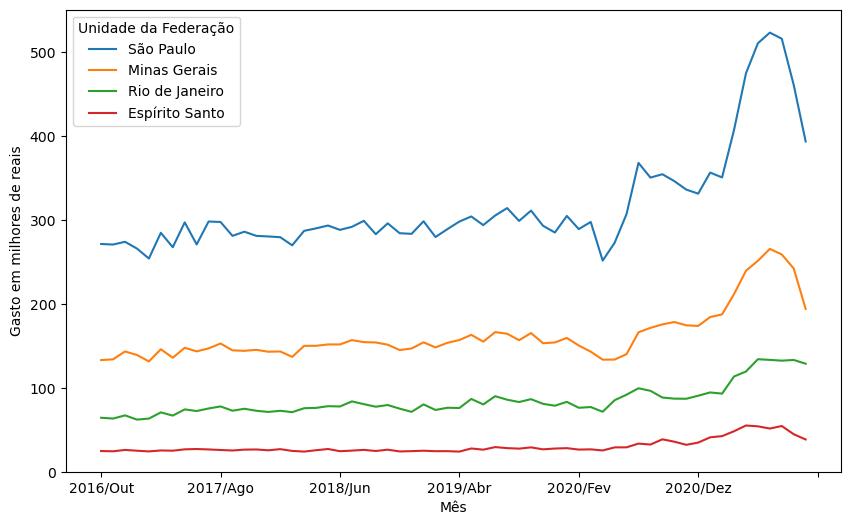

In [139]:
plota_gastos_por_mes(dados_sudeste[dados_sudeste.columns[-60:]])
plt.ylim(0,550)
plt.show()

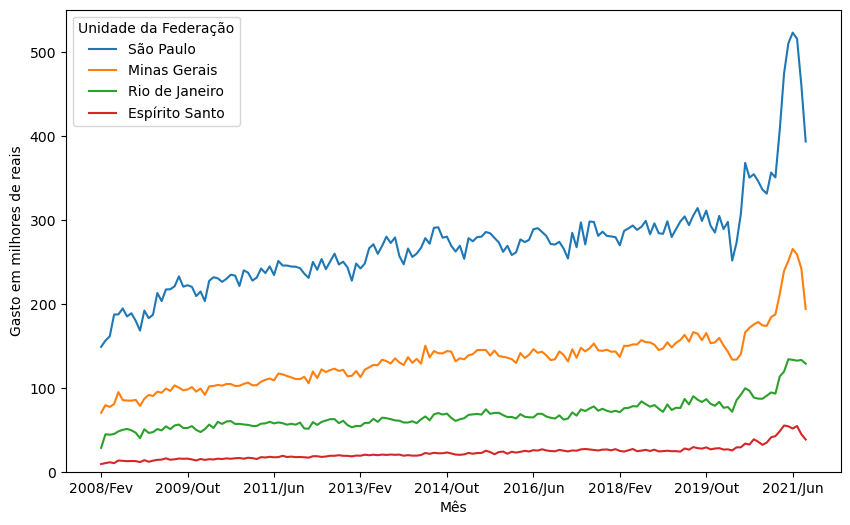

In [140]:
plota_gastos_por_mes(dados_sudeste)
plt.ylim(0,550)
plt.show()

In [141]:
# Função para criar um gráfico 
def plota_gastos_por_mes(dados,figsize=(10,6)):
    axis = dados.T.plot(figsize=figsize)
    axis.set_ylabel("Gasto em milhores de reais")
    axis.set_xlabel("Mês")

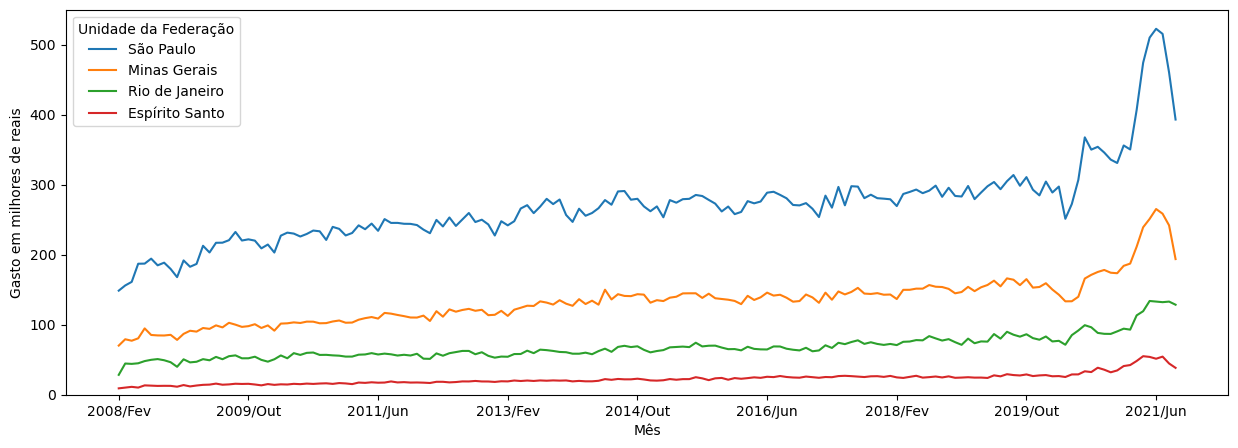

In [142]:
plota_gastos_por_mes(dados_sudeste,figsize=(15,5))
plt.ylim(0,550)
plt.show()

In [143]:
# padronizar os ticks verticais para espaçamento de 12 em 12

In [144]:
dados_sudeste

,2008/Fev,2008/Mar,2008/Abr,2008/Mai,2008/Jun,2008/Jul,2008/Ago,2008/Set,2008/Out,2008/Nov,...,2020/Dez,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,2021/Set
Unidade da Federação,,,,,,,,,,,,,,,,,,,,,
São Paulo,148.68,156.09,161.23,187.12,187.29,194.40,184.85,188.64,179.71,167.99,...,331.04,356.10,350.37,406.87,474.28,510.12,522.75,515.46,460.35,393.12
Minas Gerais,70.19,79.23,77.14,80.55,94.76,85.36,84.72,84.60,85.56,78.33,...,173.57,184.12,187.32,211.48,239.22,251.15,265.28,258.58,241.93,193.77
Rio de Janeiro,28.39,44.57,44.05,44.91,48.06,49.87,50.91,49.27,46.43,39.91,...,90.48,94.36,92.98,113.35,119.30,133.93,133.15,132.22,133.05,128.59
Espírito Santo,9.10,10.25,11.25,10.20,13.36,13.04,12.59,12.73,12.66,11.46,...,34.69,40.95,42.37,48.20,55.04,54.02,51.42,54.43,44.63,38.40


In [152]:
# Função para criar um gráfico com linhas verticais no início de cada ano
def plota_gastos_por_mes_divisao(dados, figsize=(10,6)):
    dados_transpostos = dados.T
    axis = dados_transpostos.plot(figsize=figsize)

    axis.set_ylabel("Gasto em milhões de reais")
    axis.set_xlabel("Mês")

    # Converter os índices para datetime
    datas = pd.to_datetime(dados_transpostos.index, format="%Y/%b")

    # Obter o primeiro mês disponível de cada ano
    primeiros_meses = {}
    for i, data in enumerate(datas):
        ano = data.year
        if ano not in primeiros_meses:
            primeiros_meses[ano] = i  # salva a primeira ocorrência desse ano

    # Adicionar linhas verticais e texto
    for ano, idx in primeiros_meses.items():
        axis.axvline(x=idx, color='red', linestyle='--', linewidth=1)
        axis.text(idx, axis.get_ylim()[1]*0.95, str(ano),
                  rotation=90, color='red', verticalalignment='top')


    axis.legend(loc='upper left', bbox_to_anchor=(1, 1), borderaxespad=1)

    return axis


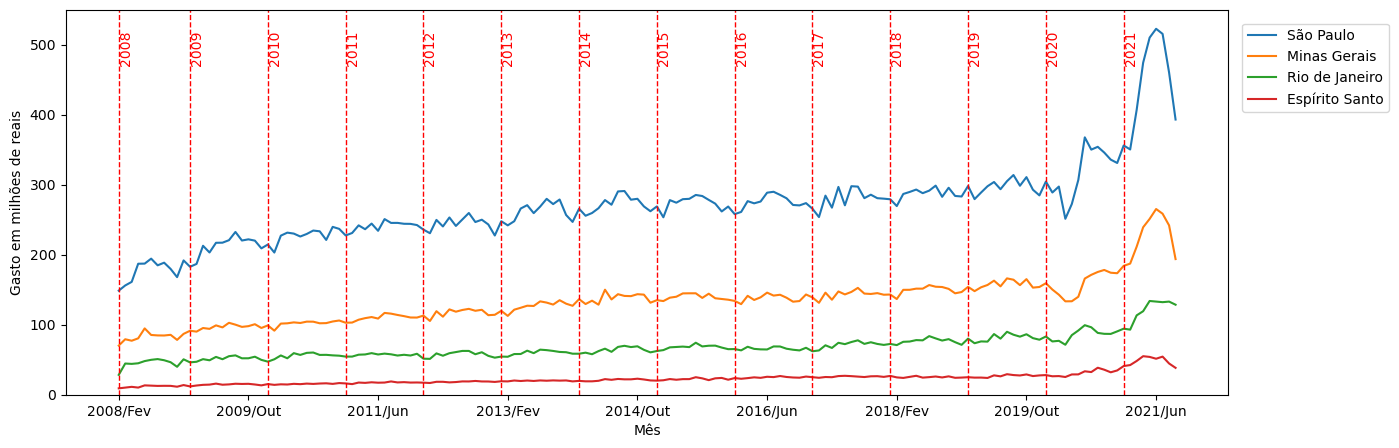

In [153]:
plota_gastos_por_mes_divisao(dados_sudeste, figsize=(15,5))
plt.ylim(0, 550)
plt.show()
